# Notebook 3: Building the Machine Learning DataSet

Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of highly-cited scientific journals using co-author metrics alone. 

## 3.1 Defining the Target Variable

### 3.1.1 Joining Together the DataSets

To have all the metrics we need to build our machine learning data set, we need to join together `papers_df`, `profile_df` and `jour_df`.

Here is `papers_df`

In [11]:
papers_df = pd.read_pickle('output/NB2_papers_df.pkl')

In [4]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_id      15696 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(6)
memory usage: 965.8+ KB


Here is `profile_df`

In [49]:
profile_df = pd.read_pickle('output/NB2_profile_df.pkl')

In [50]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              616 non-null    int16 
 1   Query           616 non-null    object
 2   profile_author  616 non-null    object
dtypes: int16(1), object(2)
memory usage: 11.0+ KB


Now let's join the `papers_df` and `profile_df` together to make the data set `join_df`

In [51]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [52]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15696 entries, 0 to 15695
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_id      15696 non-null  int16  
 14  id              15696 non-null  int16  
 15  profile_author  15696 non-null  object 
dtypes: float16(1), int16(7), int8(1), object(7)
memory usage: 1.2+ MB


We can remove `profile_id` and `id` from this data set.

In [53]:
join_df = join_df.drop(['profile_id', 'id'], axis = 1)

In [54]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15696 entries, 0 to 15695
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_author  15696 non-null  object 
dtypes: float16(1), int16(5), int8(1), object(7)
memory usage: 1.2+ MB


Here is `jour_df`

In [55]:
jour_df = pd.read_pickle('output/NB1_V2.1_jour_df.pkl')

In [56]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6280 entries, 0 to 6279
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6280 non-null   object 
 1   Type     6280 non-null   object 
 2   SJR      6202 non-null   float16
 3   H index  6280 non-null   float64
 4   Country  6280 non-null   object 
 5   Region   6280 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 257.7+ KB


Now let's inter join `jour_df` with `join_df` to make a new `join_df`.

In [57]:
join_df = pd.merge(left = join_df, right = jour_df, left_on = 'Source', right_on = 'Title')

Here is the new `join_df`

In [58]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14382 entries, 0 to 14381
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   Title_x         14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   Type_x          14382 non-null  object 
 9   ECC             14382 non-null  int16  
 10  CitesPerYear    14382 non-null  float16
 11  CitesPerAuthor  14382 non-null  int16  
 12  AuthorCount     14382 non-null  int8   
 13  profile_author  14382 non-null  object 
 14  Title_y         14382 non-null  object 
 15  Type_y          14382 non-null  object 
 16  SJR             14382 non-null  float16
 17  H index         14382 non-null 

We can remove `Title_y` (redundant to `Source`) and `Title_x` (only has one unique value) and rename `Title_x` to `EntryTitle` and `Type_y` to `PubType`.

In [59]:
join_df = join_df.drop(['Title_y', 'Type_x'], axis = 1)

In [60]:
join_df.columns = ['first_auth', 'second_auth', 'third_auth', 'Cites', 'EntryTitle', 'Year',
       'Source', 'GSRank', 'ECC', 'CitesPerYear', 'CitesPerAuthor',
       'AuthorCount', 'profile_author', 'PubType', 'SJR', 'H index', 'Country',
       'Region']

Here is the new `join_df`

In [61]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14382 entries, 0 to 14381
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float16
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  H index         14382 non-null  float64
 16  Country         14382 non-null  object 
 17  Region          14382 non-null 

### 3.1.2 Building the Target Variable

Our task is to categorize each entry into publication tiers according to their level of prestige. To achieve this, we will assign each entry to a tier based on its `H index`, which is a metric that takes into account both the number of highly cited papers and the number of citations a publication source has received. This metric is an appropriate choice for our dataset since it provides a descriptive measure of the impact and influence of a publication source.

In [110]:
# 1. Sort entries by H index
sort_df = join_df.sort_values('H index', ascending=False)

# 2. Defining the maximum number of entries per tier
tier_member_max = int(sort_df.shape[0]/3)

# 3. Defining a Dictionary to Store the Values
pub_dic = {'PubTier': [], 'H index': [], 'EntryTitle':[]}

# 4. Looping over entries to sort them into tiers
counter = 0 # tracks the number of papers in each tier
tier = 1
for i in range(sort_df.shape[0]):
    
    # If the counter is larger than the max allowed number, and the tier is not 3 (let overflow into tier 3)
    if counter > tier_member_max and tier !=3:
        # Increase the tier and reset the counter
        tier = tier + 1
        counter = 0
        
    pub_dic['PubTier'].append(tier)
    pub_dic['H index'].append(sort_df['H index'][i])
    pub_dic['EntryTitle'].append(sort_df['EntryTitle'][i])
        
    counter = counter + 1

pub_df = pd.DataFrame(pub_dic)

Let's check to be sure the number of values in `PubTier` is equal to the number of rows in `join_df`

In [97]:
pub_df['PubTier'].shape[0] == join_df.shape[0]

True

This is true, therefore each entry was accounted for. Let's check the distribution of entries in each tier.

Text(0.5, 0, 'Number of Observations in Each Tier')

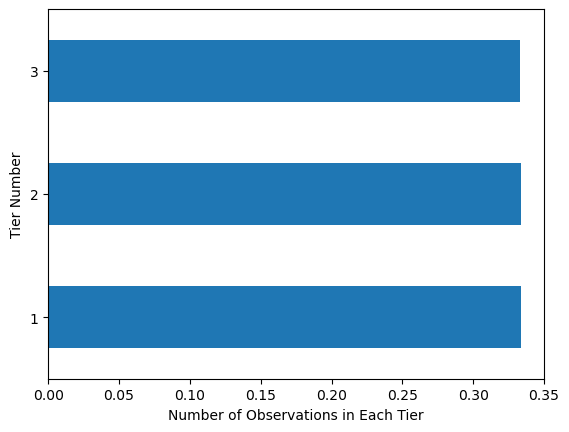

In [98]:
pub_df['PubTier'].value_counts(normalize = True).plot(kind = 'barh')
plt.ylabel('Tier Number')
plt.xlabel('Number of Observations in Each Tier')

It looks the tiers have an equal number of entries, ensuring that the target `PubTier` is equally biased towards all three tiers. Let's 

In [109]:
pub_df.groupby('PubTier')['H index'].tolist().reset_index()

AttributeError: 'SeriesGroupBy' object has no attribute 'tolist'

In [ ]:
sns.boxplot(data = tier_df, orient='h')
plt.xlabel('Publication H Index')
plt.title('Distribution of Publictaion H Indexes for Each Tier')

Let's join the values of `PubTier` onto `join_df`

In [111]:
join_df = pd.merge(left = join_df, right = pub_df, left_on = 'EntryTitle', right_on = 'EntryTitle')

Here is the new `jour_df`

In [112]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14382 entries, 0 to 14381
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float16
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  H index_x       14382 non-null  float64
 16  Country         14382 non-null  object 
 17  Region          14382 non-null 

Since the H index's were used to group the entries into tiers, they're essentially redundant top the target variable. Let's remove them from `join_df`. 

In [113]:
join_df = join_df.drop(['H index_x', 'H index_y'], axis = 1)

In [114]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14382 entries, 0 to 14381
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float16
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  Country         14382 non-null  object 
 16  Region          14382 non-null  object 
 17  PubTier         14382 non-null 

## 3.2 Expand Entries 

The aim of **Section 3.2** is to create a descriptive profile for each author by utilizing the descriptive attributes associated with each of their authored entries. To achieve this, the entries in join_df need to be expanded to allocate a separate line for each author present in the entry. The desired data structure is exemplified below.


|Name |Title| ...|
|-----|--------|----|
|d shi|low trap-state density and| ...|
|v adinolfi	 |low trap-state density and| ...|
|r comin |low trap-state density and| ...|
|h tan	| efficient and stable solution-| ...|

Let's build that new data set and call it `exapand_df1`

In [69]:
def make_df(row):
    '''
    
    Parameters:
    ----------
    row: pandas.Series 
        a Pandas Series that is a single row in the larger papers_df data frame. This row should contain
    information about the paper, including the columns 'first_auth', 'second_auth', 'third_auth'.
    
    Return:
    -------
    ret_df: pandas.DataFrame 
        a new data frame that has repeated information about each paper for each author. 
        It also has new columns 'AuthorName' and 'AuthorRank'
    
    '''
    
    # NumpPy Array of the author names
    auth_list = np.unique(row[['first_auth', 'second_auth', 'third_auth', 'profile_author']].values)
    
    # Series of values exlcuding the first, second and third author columns
    new_ser = row.drop(['first_auth', 'second_auth', 'third_auth', 'profile_author'])
    
    # Initiate a New Data Fame
    ret_df = pd.DataFrame()
    
    # Adding new rows to the data frame for each author in the paper
    for i in range(auth_list.shape[0]):
        auth_ser = pd.Series({'AuthorName': auth_list[i], 'AuthorRank': i+1})
        concat_ser = pd.concat([auth_ser, new_ser])
        
        concat_df = pd.DataFrame([concat_ser])
        ret_df = pd.concat([ret_df, concat_df], axis = 0)
    
    return ret_df

In [116]:
from tqdm.notebook import tqdm 

# Initiate DataFrame
expand_df1 = pd.DataFrame()

# Adding new data frames (this takes about 4-5 minutes)
# Using a for loop instead of .apply() to be able to use the tqdm module to track the progress
for i in tqdm(range(join_df.shape[0])):
    row = join_df.loc[i, :]
    
    # Make a new set of dataframe
    ret_df = make_df(row)
     
    # Add to new df
    expand_df1 = pd.concat([expand_df1, ret_df], axis = 0)

  0%|          | 0/14382 [00:00<?, ?it/s]

In [117]:
expand_df1 = expand_df1.reset_index(drop = True)

Here is the `expand_df1`

In [118]:
expand_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57203 entries, 0 to 57202
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AuthorName      57203 non-null  object 
 1   AuthorRank      57203 non-null  int64  
 2   Cites           57203 non-null  int16  
 3   EntryTitle      57203 non-null  object 
 4   Year            57203 non-null  int16  
 5   Source          57203 non-null  object 
 6   GSRank          57203 non-null  int16  
 7   ECC             57203 non-null  int16  
 8   CitesPerYear    57203 non-null  float16
 9   CitesPerAuthor  57203 non-null  int16  
 10  AuthorCount     57203 non-null  int8   
 11  PubType         57203 non-null  object 
 12  SJR             57203 non-null  float16
 13  Country         57203 non-null  object 
 14  Region          57203 non-null  object 
 15  PubTier         57203 non-null  int64  
dtypes: float16(2), int16(5), int64(2), int8(1), object(6)
memory usage: 4.3+ MB


Here, we added a new column `AuthorRank` which refers to the original placement of the author (first, second, third, profile).

Let's check for nulls

In [119]:
expand_df1.isna().sum()

AuthorName        0
AuthorRank        0
Cites             0
EntryTitle        0
Year              0
Source            0
GSRank            0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
PubType           0
SJR               0
Country           0
Region            0
PubTier           0
dtype: int64

There are no null values introduced.

Now that we have the new data frame, we can more easily build a profile for each author. To do so, we will have to aggregate on the numeric *feature* columns, meaning information from the object type columns will be excluded. Ideally, these columns can be converted into numeric data types to serve as additional features, but for the sake of time we'll only consider the current numeric columns.

In [120]:
sub_df = pd.concat([expand_df1.loc[:, 'AuthorName'], expand_df1.select_dtypes('number').drop('PubTier', axis = 1)], axis = 1)

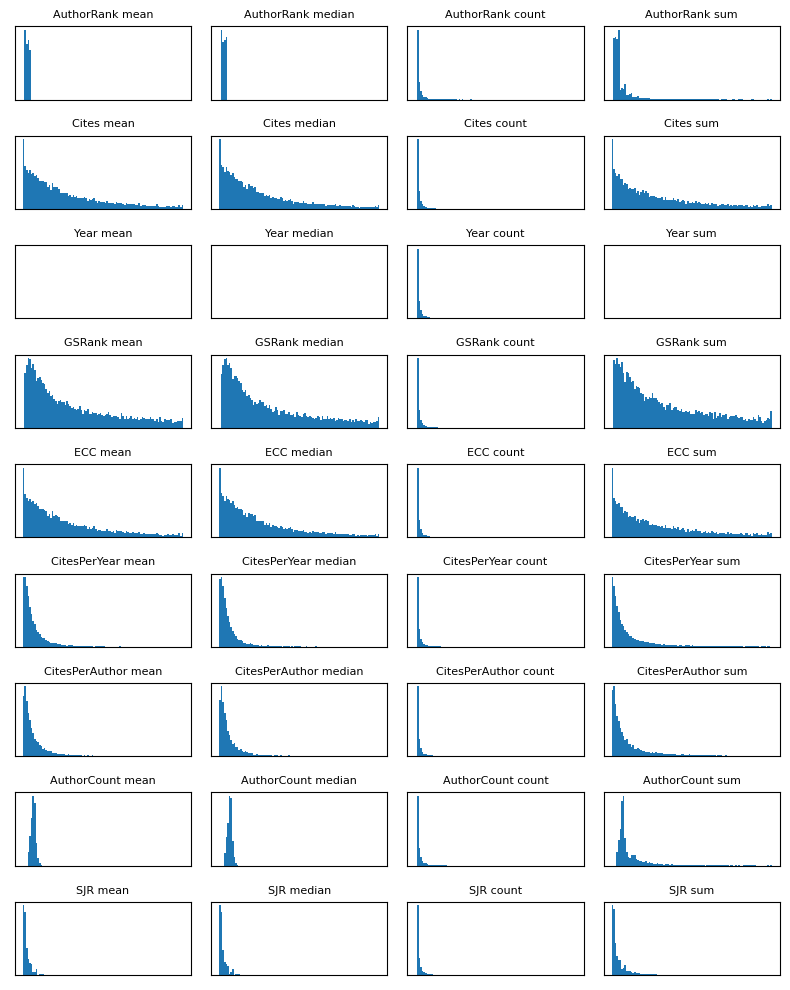

In [131]:
grouped_df = sub_df.groupby('AuthorName').agg(['mean', 'median', 'count', 'sum'])

level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

fig = plt.figure(figsize = (8, 10))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    ax.hist(grouped_df[l1][l2], bins = 100, range = (0, 100))
    ax.set_title(f'{l1} {l2}', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    
    i += 1
    
fig.tight_layout()

It looks like, for the most part, the mean and median of each feature has a similar right-skew distribution as count and sum. The exceptions are `AuthorCount` and `AuthorRank` which have a move *normal* distribution for the mean and median, with median looking to provide a more normal distribution for `AuthorCount`. Additionally, `Year` does not show a distribution except for count. Let's rescale the values using a log to see if the distribution changes. 

C:\Users\Grumb\AppData\Local\Temp\ipykernel_131244\1330083773.py:2: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


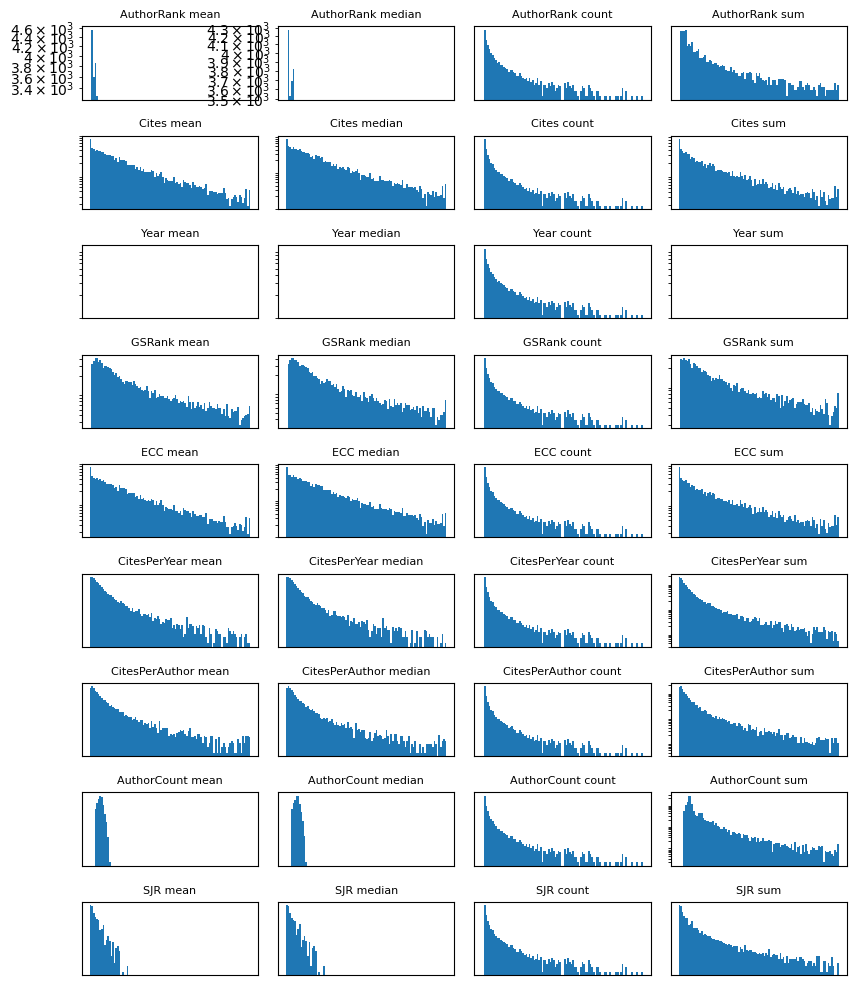

In [132]:
for (row, col), ax in np.ndenumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([],[])
    ax.set_xticks([],[])
fig

It looks like re-scaling the values using the log made the distributions any more normally distributed. Therefore, let's aggregate the numeric features for each author by their median, since that statistic provided the most normal distribution for `AuthorCount`. However, from the earlier results we saw that `Year` did not have a distribution when grouped by median, so we'll group `Year` by count instead.

In [135]:
exapand_df2

,AuthorName,AuthorRank,Cites,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,SJR
0,a a petrov,1.0,3.0,2020.0,53.0,3.0,1.000000,1.0,5.0,0.705078
1,a abbasi,1.0,54.0,2016.0,8.0,54.0,7.710938,11.0,5.0,0.464111
2,a abdollahi,1.0,150.0,2018.0,52.0,150.0,30.000000,38.0,4.0,8.664062
3,a abherve,1.0,33.0,2018.0,44.0,33.0,6.601562,6.0,6.0,2.929688
4,a ablat,1.0,18.0,2018.0,256.0,18.0,3.599609,2.0,8.0,1.004883
...,...,...,...,...,...,...,...,...,...,...
15298,zy xia,4.0,74.0,2014.0,92.0,74.0,8.218750,11.0,7.0,0.682129
15299,zy xiao,4.0,97.0,2013.0,80.0,97.0,9.703125,10.0,10.0,0.667969
15300,zy zhan,4.0,65.5,2005.5,124.5,65.5,3.730469,9.0,7.5,1.281250
15301,zz dai,4.0,6.0,2022.0,317.0,6.0,6.000000,1.0,7.0,3.224609


In [148]:
# For columns with Mean
gb1 = sub_df.drop('Year', axis = 1).groupby('AuthorName').mean()
gb1.columns = np.asarray(['_'.join(['Mean', i]) for i in gb1.columns])

# For columns with Count
gb2 = sub_df.groupby('AuthorName')['Year'].count().reset_index(name = 'Count_Year')

In [149]:
# Merge the two data frames together
gb_full = pd.merge(gb1, gb2, left_on = 'AuthorName', right_on = 'AuthorName')

Let's check if there are any null values.

In [150]:
gb_full.isna().sum()

AuthorName             0
Mean_AuthorRank        0
Mean_Cites             0
Mean_GSRank            0
Mean_ECC               0
Mean_CitesPerYear      0
Mean_CitesPerAuthor    0
Mean_AuthorCount       0
Mean_SJR               0
Count_Year             0
dtype: int64

There are no null values. Let's now join these values onto `join_df` by joining onto the author names.

In [163]:
auth_subcols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']

# making a copy to test the method
test_df = join_df.copy()
for i in auth_subcols:
    # Making a copy so that the original data frame isn't overwritten
    gb_df_copy = gb_full.copy()
    
    # Renaming columns based on the author standing
    gb_df_copy.columns = ['AuthorName'] + ['_'.join([i, j]) for j in gb_df_copy.columns[1:]]
    
    # Merge data frames
    test_df = pd.merge(left = test_df, right = gb_df_copy, left_on = i, right_on = 'AuthorName').drop('AuthorName', axis = 1)

In [165]:
join_df = test_df.reset_index(drop = True)

Here is the new `join_df`

In [166]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 54 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   first_auth                          14382 non-null  object 
 1   second_auth                         14382 non-null  object 
 2   third_auth                          14382 non-null  object 
 3   Cites                               14382 non-null  int16  
 4   EntryTitle                          14382 non-null  object 
 5   Year                                14382 non-null  int16  
 6   Source                              14382 non-null  object 
 7   GSRank                              14382 non-null  int16  
 8   ECC                                 14382 non-null  int16  
 9   CitesPerYear                        14382 non-null  float16
 10  CitesPerAuthor                      14382 non-null  int16  
 11  AuthorCount                         14382

We now have a data frame with aggregated statistics for each author to use in the machine learning model! As previously mentioned, for this model we will only consider standing numeric data type columns, so all object type columns will be removed. Additionally, because we want to train the model on aggregated statistics for each author and *not* statistics for each citation entry, the original metrics for each citation entry will be removed as well. Let's call this new data frame `ml_df`.

In [171]:
ml_df = join_df.select_dtypes('number').drop(['Cites', 'Year', 'GSRank', 'ECC', 'CitesPerAuthor', 'CitesPerYear', 'AuthorCount', 'SJR'], axis = 1)

Here is `ml_df`

In [172]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   PubTier                             14382 non-null  int64  
 1   first_auth_Mean_AuthorRank          14382 non-null  float64
 2   first_auth_Mean_Cites               14382 non-null  float64
 3   first_auth_Mean_GSRank              14382 non-null  float64
 4   first_auth_Mean_ECC                 14382 non-null  float64
 5   first_auth_Mean_CitesPerYear        14382 non-null  float16
 6   first_auth_Mean_CitesPerAuthor      14382 non-null  float64
 7   first_auth_Mean_AuthorCount         14382 non-null  float64
 8   first_auth_Mean_SJR                 14382 non-null  float16
 9   first_auth_Count_Year               14382 non-null  int64  
 10  second_auth_Mean_AuthorRank         14382 non-null  float64
 11  second_auth_Mean_Cites              14382

Finally, let's see if we can reduce the memory usage for `ml_df` by changing the column data types.

In [180]:
# Initiate arr of data types
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray(['None'] + [f'float{i}' for i in arr[1:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

In [189]:
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray(['None'] + [f'float{i}' for i in arr[1:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

df = ml_df
cols = ml_df.columns

for col in cols:
    max_val = df[col].max()
    #print(f'The max value in the {col} column is {max_val}')
    
    # checking if the original data type is int or float
    if df[col].dtype in arr[:,0]:
        type_tag = 0
    elif df[col].dtype in arr[:,1]:
        type_tag = 1
    
    # Iterating over the rows of the MaximumValues
    for i in range(arr[:,3].shape[0]): 
        if max_val < int(arr[i,3]):
            if type_tag == 1 and i == 0:
                pass
            else:
                #print(f'The type for {col} is being changed to {arr[i,type_tag]}')
                #print('\n')
                df[col] = df[col].astype(arr[i,0])
                break

In [190]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   PubTier                             14382 non-null  int8 
 1   first_auth_Mean_AuthorRank          14382 non-null  int8 
 2   first_auth_Mean_Cites               14382 non-null  int16
 3   first_auth_Mean_GSRank              14382 non-null  int16
 4   first_auth_Mean_ECC                 14382 non-null  int16
 5   first_auth_Mean_CitesPerYear        14382 non-null  int16
 6   first_auth_Mean_CitesPerAuthor      14382 non-null  int16
 7   first_auth_Mean_AuthorCount         14382 non-null  int8 
 8   first_auth_Mean_SJR                 14382 non-null  int8 
 9   first_auth_Count_Year               14382 non-null  int16
 10  second_auth_Mean_AuthorRank         14382 non-null  int8 
 11  second_auth_Mean_Cites              14382 non-null  int16
 12  seco

Reducing the data types, we were able to reduce the memory usage of `ml_df` by 3 MB!

Let's save `ml_df` as a pickle for implementation into machine learning models.

In [192]:
ml_df.to_pickle('output/NB3_ml_df.pkl')

---